<a href="https://colab.research.google.com/github/anwayshimpne/10cgpa/blob/main/Dosha_Detection_and__Medical_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()  # select vitalsign.csv and triage.csv


Saving triage.csv to triage.csv


In [3]:
import pandas as pd

# 1) Load raw CSVs
vitals = pd.read_csv("vitalsign.csv")
triage = pd.read_csv("triage.csv")

print("Vitals columns:", vitals.columns.tolist())
print("Triage columns:", triage.columns.tolist())
print("Vitals shape:", vitals.shape)
print("Triage shape:", triage.shape)

# 2) Basic cleaning and type fixes

# Parse time columns
vitals['charttime'] = pd.to_datetime(vitals['charttime'])
if 'intime' in triage.columns:
    triage['intime'] = pd.to_datetime(triage['intime'], errors='coerce')

# Temperature: Fahrenheit -> Celsius
def f_to_c(f):
    return (f - 32) * 5.0 / 9.0

if 'temperature' in vitals.columns:
    vitals['temperature_c'] = f_to_c(vitals['temperature'])
if 'temperature' in triage.columns:
    triage['temperature_c'] = f_to_c(triage['temperature'])

# 3) Standardize column names to our common schema
vitals_std = pd.DataFrame({
    'subject_id': vitals['subject_id'],
    'stay_id': vitals.get('stay_id', pd.NA),
    'timestamp': vitals['charttime'],
    'heart_rate': vitals.get('heartrate'),
    'spo2': vitals.get('o2sat'),
    'temperature_c': vitals.get('temperature_c'),
    'resp_rate': vitals.get('resprate'),
    'sbp': vitals.get('sbp'),
    'dbp': vitals.get('dbp'),
    'rhythm': vitals.get('rhythm'),
    'pain': vitals.get('pain'),
})
vitals_std['source'] = 'mimic_ed_vitals'

triage_std = pd.DataFrame({
    'subject_id': triage['subject_id'],
    'stay_id': triage.get('stay_id', pd.NA),
    'timestamp': triage.get('intime', pd.NaT),
    'heart_rate': triage.get('heartrate'),
    'spo2': triage.get('o2sat'),
    'temperature_c': triage.get('temperature_c'),
    'resp_rate': triage.get('resprate'),
    'sbp': triage.get('sbp'),
    'dbp': triage.get('dbp'),
})
triage_std['source'] = 'mimic_ed_triage'

# 4) Keep only rows with at least HR + Temp + SpO2 for Dosha rules
def has_core_vitals(df):
    return df['heart_rate'].notna() & df['temperature_c'].notna() & df['spo2'].notna()

vitals_core = vitals_std[has_core_vitals(vitals_std)].copy()
triage_core = triage_std[has_core_vitals(triage_std)].copy()

print("Vitals with core vitals:", vitals_core.shape)
print("Triage with core vitals:", triage_core.shape)

# 5) Combine both into one dataframe
mimic_ed_combined = pd.concat([vitals_core, triage_core], ignore_index=True)

# 6) Sort by subject and time
mimic_ed_combined = mimic_ed_combined.sort_values(
    by=['subject_id', 'timestamp']
).reset_index(drop=True)

mimic_ed_combined.head()


Vitals columns: ['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'rhythm', 'pain']
Triage columns: ['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint']
Vitals shape: (1038, 11)
Triage shape: (222, 11)
Vitals with core vitals: (562, 12)
Triage with core vitals: (194, 10)


,subject_id,stay_id,timestamp,heart_rate,spo2,temperature_c,resp_rate,sbp,dbp,rhythm,pain,source
0,10000032,33258284,2180-05-06 23:04:00,79.0,98.0,36.500000,16.0,107.0,60.0,NaN,0,mimic_ed_vitals
1,10000032,38112554,2180-06-26 18:42:00,76.0,95.0,36.611111,18.0,95.0,64.0,NaN,5,mimic_ed_vitals
2,10000032,38112554,2180-06-26 20:54:00,86.0,93.0,36.611111,17.0,96.0,57.0,NaN,NaN,mimic_ed_vitals
3,10000032,32952584,2180-07-22 18:37:00,86.0,98.0,36.888889,20.0,65.0,37.0,NaN,NaN,mimic_ed_vitals
4,10000032,32952584,2180-07-22 19:47:00,85.0,98.0,36.777778,18.0,81.0,38.0,NaN,0,mimic_ed_vitals


In [4]:
mimic_ed_combined.to_csv("mimic_ed_clean.csv", index=False)
mimic_ed_combined.to_parquet("mimic_ed_clean.parquet", index=False)


In [5]:
# Dataset Testing
print("Final combined dataset:")
print(mimic_ed_combined[['heart_rate', 'spo2', 'temperature_c']].describe())

print("\nMissing values per column:")
print(mimic_ed_combined[['heart_rate', 'spo2', 'temperature_c', 'resp_rate']].isnull().sum())

print("\nSubjects with multiple readings:")
print(mimic_ed_combined['subject_id'].value_counts().head(10))


Final combined dataset:
       heart_rate        spo2  temperature_c
count  756.000000  756.000000     756.000000
mean    87.246032   97.966931      35.097648
std     18.133582    2.231672       7.536023
min     43.000000   78.000000      -0.333333
25%     74.000000   97.000000      36.500000
50%     85.000000   98.000000      36.722222
75%     99.250000  100.000000      36.944444
max    157.000000  100.000000      39.166667

Missing values per column:
heart_rate       0
spo2             0
temperature_c    0
resp_rate        3
dtype: int64

Subjects with multiple readings:
subject_id
10014354    88
10002930    61
10015860    54
10039708    51
10040025    45
10037928    40
10005866    38
10012853    27
10002428    22
10026406    21
Name: count, dtype: int64


In [6]:
# dosha Labelling
def assign_dosha_refined(row):
    hr = row['heart_rate']
    temp_c = row['temperature_c']
    spo2 = row['spo2']

    scores = {'vata': 0.0, 'pitta': 0.0, 'kapha': 0.0}

    # Vata (cold, dry, nervous): high HR, low temp, low SpO2
    if hr > 90: scores['vata'] += 2
    if temp_c < 36.2: scores['vata'] += 2
    if spo2 < 96: scores['vata'] += 1

    # Pitta (hot, sharp, inflamed): high HR, high temp, normal SpO2
    if hr > 90: scores['pitta'] += 1
    if temp_c > 36.8: scores['pitta'] += 2
    if spo2 >= 97: scores['pitta'] += 1

    # Kapha (heavy, stable, grounded): low HR, normal temp, good SpO2
    if hr < 75: scores['kapha'] += 2
    if 36.2 <= temp_c <= 36.8: scores['kapha'] += 1
    if spo2 >= 98: scores['kapha'] += 2

    dominant = max(scores, key=scores.get)
    confidence = max(scores.values())

    return f"{dominant} ({confidence:.1f})"

# Apply to your cleaned data
mimic_ed_combined['dosha_label'] = mimic_ed_combined.apply(assign_dosha_refined, axis=1)

print("Dosha distribution:")
print(mimic_ed_combined['dosha_label'].value_counts().sort_index())

# Save labeled version
mimic_ed_combined.to_csv("mimic_ed_labeled.csv", index=False)
print("\n✅ Saved mimic_ed_labeled.csv with Dosha labels!")


Dosha distribution:
dosha_label
kapha (1.0)      5
kapha (3.0)    235
kapha (4.0)     40
kapha (5.0)     90
pitta (1.0)     18
pitta (2.0)     24
pitta (3.0)     78
pitta (4.0)    112
vata (1.0)      13
vata (2.0)      74
vata (3.0)      44
vata (4.0)      22
vata (5.0)       1
Name: count, dtype: int64

✅ Saved mimic_ed_labeled.csv with Dosha labels!


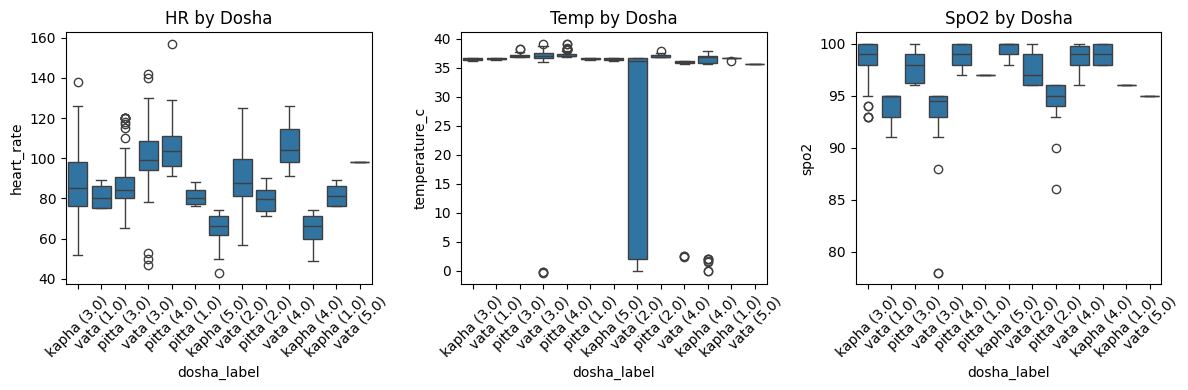

In [7]:
# Quick Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dosha vs vitals
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(data=mimic_ed_combined, x='dosha_label', y='heart_rate')
plt.xticks(rotation=45)
plt.title('HR by Dosha')

plt.subplot(1, 3, 2)
sns.boxplot(data=mimic_ed_combined, x='dosha_label', y='temperature_c')
plt.xticks(rotation=45)
plt.title('Temp by Dosha')

plt.subplot(1, 3, 3)
sns.boxplot(data=mimic_ed_combined, x='dosha_label', y='spo2')
plt.xticks(rotation=45)
plt.title('SpO2 by Dosha')

plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

       kapha       0.99      0.97      0.98       111
       pitta       0.99      1.00      0.99        70
        vata       0.96      0.98      0.97        46

    accuracy                           0.98       227
   macro avg       0.98      0.98      0.98       227
weighted avg       0.98      0.98      0.98       227



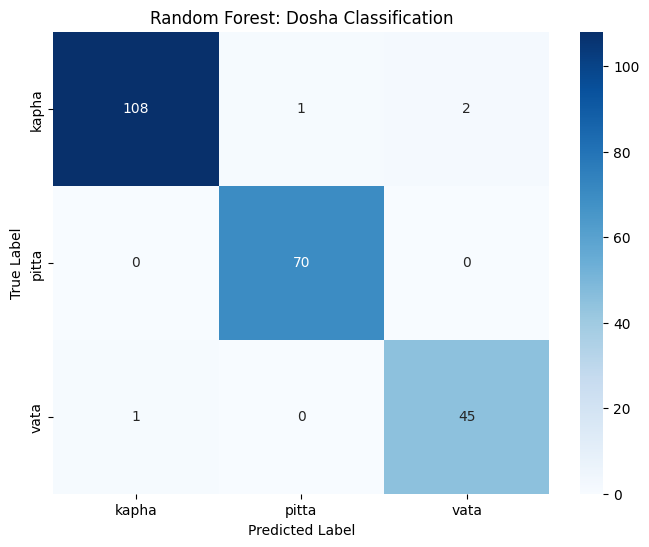


Feature Importance:
         feature  importance
2  temperature_c    0.544924
0     heart_rate    0.252161
1           spo2    0.202915


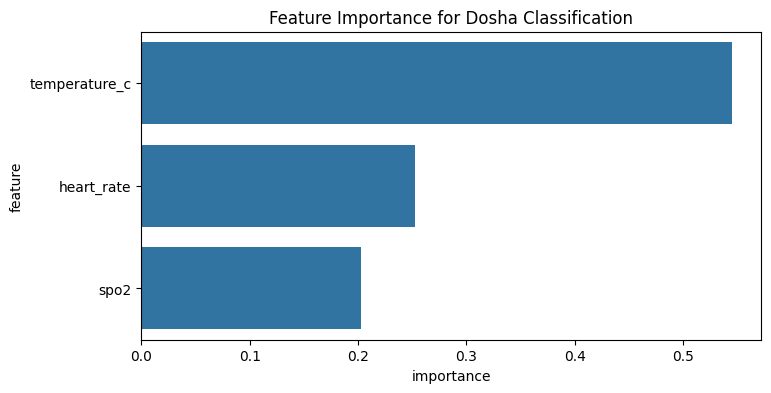

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Clean labels for ML (just the dosha name)
mimic_ed_combined['dosha_simple'] = mimic_ed_combined['dosha_label'].str.split(' ').str[0]

# Features and target
features = ['heart_rate', 'spo2', 'temperature_c']
X = mimic_ed_combined[features].fillna(mimic_ed_combined[features].mean())
y = mimic_ed_combined['dosha_simple']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['kapha', 'pitta', 'vata'],
            yticklabels=['kapha', 'pitta', 'vata'])
plt.title('Random Forest: Dosha Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importances)

plt.figure(figsize=(8, 4))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Feature Importance for Dosha Classification')
plt.show()


<Figure size 640x480 with 0 Axes>

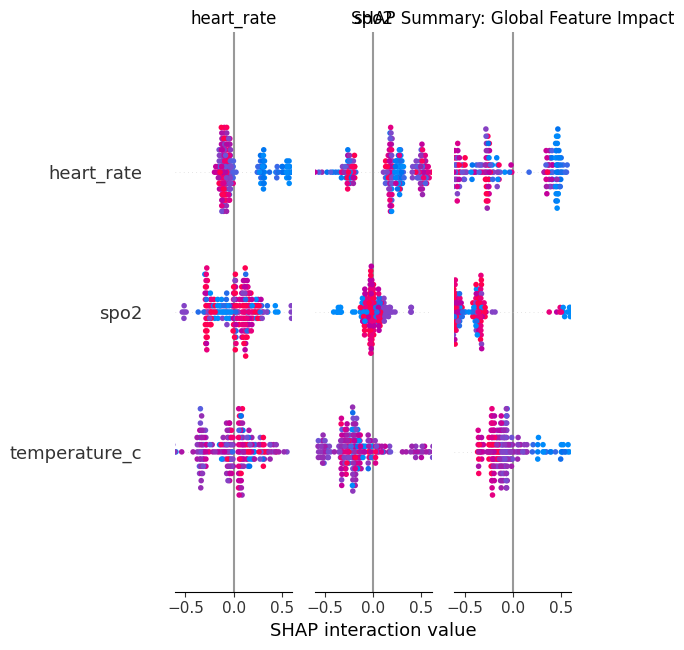

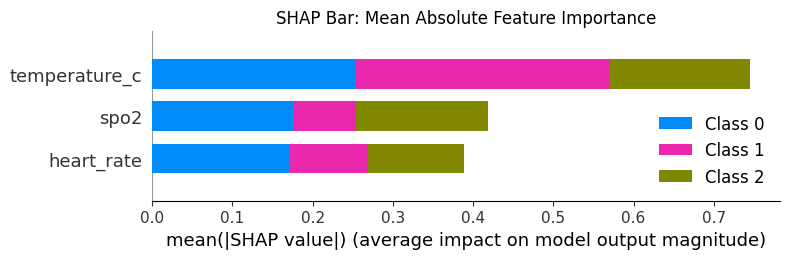

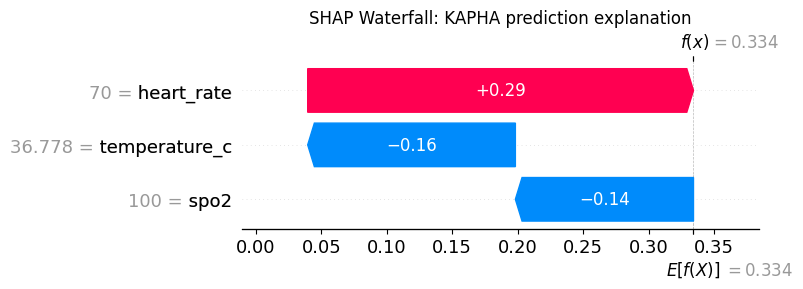

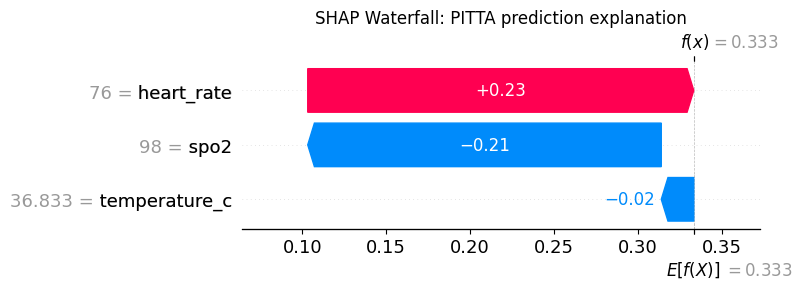

IndexError: index 9 is out of bounds for axis 0 with size 3

In [12]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Build SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Step 2: Global Summary Plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary: Global Feature Impact')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 3: Global Bar Plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Bar: Mean Absolute Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 4: Waterfall for one sample per class
class_names = list(rf.classes_)
for cls_name in class_names:
    # Find first test sample of this class
    idx = y_test[y_test == cls_name].index[0]
    pos = list(X_test.index).index(idx)
    cls_idx = class_names.index(cls_name)

    shap_exp = shap.Explanation(
        values=shap_values[cls_idx][pos],
        base_values=explainer.expected_value[cls_idx],
        data=X_test.iloc[pos].values,
        feature_names=features
    )
    plt.figure()
    shap.plots.waterfall(shap_exp, show=False)
    plt.title(f'SHAP Waterfall: {cls_name.upper()} prediction explanation')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{cls_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Step 5: Cross-validation for publication robustness
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("=" * 40)
print("5-Fold Cross Validation Results:")
print(f"Fold scores: {cv_scores.round(4)}")
print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 40)

# Step 6: Save final model
import joblib
joblib.dump(rf, 'dosha_rf_model.pkl')
print("✅ Model saved as dosha_rf_model.pkl")
print("✅ SHAP plots saved!")


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())


CV scores: [0.99342105 0.99337748 0.98675497 0.98013245 1.        ]
Mean CV accuracy: 0.9907371906587661
Std CV accuracy: 0.006757107688251769


In [15]:
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())


CV scores: [0.99342105 0.99337748 0.98675497 0.98013245 1.        ]
Mean CV accuracy: 0.9907371906587661
Std CV accuracy: 0.006757107688251769


In [16]:
import json
import joblib
import pandas as pd
import os

# Save model
joblib.dump(rf, "dosha_rf_model.pkl")

# Save feature importance
importances.to_csv("feature_importance.csv", index=False)

# Save CV metrics
metrics = {
    "cv_scores": cv_scores.tolist(),
    "cv_mean_accuracy": float(cv_scores.mean()),
    "cv_std_accuracy": float(cv_scores.std())
}

with open("cv_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Save final labeled dataset
mimic_ed_combined.to_csv("mimic_ed_labeled_final.csv", index=False)

print("Saved files:")
for f in os.listdir():
    if f.endswith(".png") or f.endswith(".csv") or f.endswith(".json") or f.endswith(".pkl"):
        print(f)


Saved files:
mimic_ed_clean.csv
shap_bar.png
mimic_ed_labeled.csv
triage.csv
shap_summary_beeswarm.png
vitalsign.csv
feature_importance.csv
cv_metrics.json
mimic_ed_labeled_final.csv
shap_waterfall_kapha.png
shap_summary.png
dosha_rf_model.pkl
shap_waterfall_pitta.png


In [17]:
summary_text = f"""
Dosha Classification Summary
----------------------------
Dataset rows: {len(mimic_ed_combined)}
Classes: {sorted(mimic_ed_combined['dosha_simple'].unique().tolist())}

Cross-validation scores: {cv_scores}
Mean CV accuracy: {cv_scores.mean():.4f}
Std CV accuracy: {cv_scores.std():.4f}

Feature importances:
{importances.to_string(index=False)}
"""

with open("results_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)



Dosha Classification Summary
----------------------------
Dataset rows: 756
Classes: ['kapha', 'pitta', 'vata']

Cross-validation scores: [0.99342105 0.99337748 0.98675497 0.98013245 1.        ]
Mean CV accuracy: 0.9907
Std CV accuracy: 0.0068

Feature importances:
      feature  importance
temperature_c    0.544924
   heart_rate    0.252161
         spo2    0.202915



In [18]:
# Step 1: Create a prototype herb recommendation knowledge base
herb_knowledge = {
    "vata": {
        "primary_herbs": ["Ashwagandha", "Brahmi", "Shatavari"],
        "diet_support": [
            "Warm cooked meals",
            "Soups and khichdi",
            "Regular meal timing",
            "Avoid excess cold/dry foods"
        ],
        "lifestyle_support": [
            "Good sleep routine",
            "Gentle yoga",
            "Stress reduction",
            "Warm hydration"
        ],
        "prototype_note": "Grounding and nourishing support"
    },
    "pitta": {
        "primary_herbs": ["Guduchi", "Amla", "Shatavari"],
        "diet_support": [
            "Cooling foods",
            "Avoid overly spicy/oily meals",
            "Hydration",
            "Fresh fruits and lighter meals"
        ],
        "lifestyle_support": [
            "Heat management",
            "Moderate exercise",
            "Relaxation",
            "Avoid overexertion"
        ],
        "prototype_note": "Cooling and soothing support"
    },
    "kapha": {
        "primary_herbs": ["Ginger", "Triphala", "Cinnamon"],
        "diet_support": [
            "Light warm meals",
            "Reduce heavy/oily foods",
            "Avoid overeating",
            "Prefer stimulating spices in moderation"
        ],
        "lifestyle_support": [
            "Daily exercise",
            "Active routine",
            "Avoid oversleeping",
            "Warm water intake"
        ],
        "prototype_note": "Stimulating and lightening support"
    }
}

print("✅ herb_knowledge created")
print(herb_knowledge)


✅ herb_knowledge created
{'vata': {'primary_herbs': ['Ashwagandha', 'Brahmi', 'Shatavari'], 'diet_support': ['Warm cooked meals', 'Soups and khichdi', 'Regular meal timing', 'Avoid excess cold/dry foods'], 'lifestyle_support': ['Good sleep routine', 'Gentle yoga', 'Stress reduction', 'Warm hydration'], 'prototype_note': 'Grounding and nourishing support'}, 'pitta': {'primary_herbs': ['Guduchi', 'Amla', 'Shatavari'], 'diet_support': ['Cooling foods', 'Avoid overly spicy/oily meals', 'Hydration', 'Fresh fruits and lighter meals'], 'lifestyle_support': ['Heat management', 'Moderate exercise', 'Relaxation', 'Avoid overexertion'], 'prototype_note': 'Cooling and soothing support'}, 'kapha': {'primary_herbs': ['Ginger', 'Triphala', 'Cinnamon'], 'diet_support': ['Light warm meals', 'Reduce heavy/oily foods', 'Avoid overeating', 'Prefer stimulating spices in moderation'], 'lifestyle_support': ['Daily exercise', 'Active routine', 'Avoid oversleeping', 'Warm water intake'], 'prototype_note': 'Sti

In [19]:
# Step 2: Recommendation function
def parse_dosha_and_score(label):
    if "(" in label and ")" in label:
        dosha = label.split(" ")[0].strip().lower()
        score = float(label.split("(")[1].split(")")[0])
    else:
        dosha = str(label).strip().lower()
        score = None
    return dosha, score

def confidence_bucket(score):
    if score is None:
        return "unknown"
    if score >= 4:
        return "high"
    elif score >= 2:
        return "medium"
    return "low"

def get_recommendation(row):
    dosha, score = parse_dosha_and_score(row["dosha_label"])
    kb = herb_knowledge.get(dosha, {})

    return {
        "dosha_predicted": dosha,
        "dosha_score": score,
        "confidence_level": confidence_bucket(score),
        "primary_herb_1": kb.get("primary_herbs", ["", "", ""])[0] if len(kb.get("primary_herbs", [])) > 0 else "",
        "primary_herb_2": kb.get("primary_herbs", ["", "", ""])[1] if len(kb.get("primary_herbs", [])) > 1 else "",
        "primary_herb_3": kb.get("primary_herbs", ["", "", ""])[2] if len(kb.get("primary_herbs", [])) > 2 else "",
        "diet_support": " | ".join(kb.get("diet_support", [])),
        "lifestyle_support": " | ".join(kb.get("lifestyle_support", [])),
        "prototype_note": kb.get("prototype_note", "")
    }


In [20]:
# Step 3: Apply recommendations to the dataset
recommendation_df = mimic_ed_combined.apply(get_recommendation, axis=1, result_type="expand")

# Merge with original dataset
mimic_ed_recommendations = pd.concat([mimic_ed_combined.reset_index(drop=True),
                                      recommendation_df.reset_index(drop=True)], axis=1)

# Save final CSV
mimic_ed_recommendations.to_csv("mimic_ed_with_herb_recommendations.csv", index=False)

print("✅ Saved: mimic_ed_with_herb_recommendations.csv")
print(mimic_ed_recommendations[
    ["dosha_label", "dosha_predicted", "confidence_level",
     "primary_herb_1", "primary_herb_2", "primary_herb_3"]
].head(10))


✅ Saved: mimic_ed_with_herb_recommendations.csv
   dosha_label dosha_predicted confidence_level primary_herb_1 primary_herb_2  \
0  kapha (3.0)           kapha           medium         Ginger       Triphala   
1   vata (1.0)            vata              low    Ashwagandha         Brahmi   
2   vata (1.0)            vata              low    Ashwagandha         Brahmi   
3  pitta (3.0)           pitta           medium        Guduchi           Amla   
4  kapha (3.0)           kapha           medium         Ginger       Triphala   
5   vata (1.0)            vata              low    Ashwagandha         Brahmi   
6   vata (3.0)            vata           medium    Ashwagandha         Brahmi   
7  pitta (4.0)           pitta             high        Guduchi           Amla   
8  kapha (3.0)           kapha           medium         Ginger       Triphala   
9  pitta (3.0)           pitta           medium        Guduchi           Amla   

  primary_herb_3  
0       Cinnamon  
1      Shatavari  
2  

In [21]:
# Step 4: Show one example per dosha
for d in ["vata", "pitta", "kapha"]:
    sample = mimic_ed_recommendations[mimic_ed_recommendations["dosha_predicted"] == d].head(1)
    print("\n" + "="*60)
    print(f"DOSHA: {d.upper()}")
    print(sample[[
        "heart_rate", "spo2", "temperature_c",
        "dosha_label", "primary_herb_1", "primary_herb_2", "primary_herb_3",
        "diet_support", "lifestyle_support", "prototype_note"
    ]].to_string(index=False))



DOSHA: VATA
 heart_rate  spo2  temperature_c dosha_label primary_herb_1 primary_herb_2 primary_herb_3                                                                              diet_support                                                    lifestyle_support                   prototype_note
       76.0  95.0      36.611111  vata (1.0)    Ashwagandha         Brahmi      Shatavari Warm cooked meals | Soups and khichdi | Regular meal timing | Avoid excess cold/dry foods Good sleep routine | Gentle yoga | Stress reduction | Warm hydration Grounding and nourishing support

DOSHA: PITTA
 heart_rate  spo2  temperature_c dosha_label primary_herb_1 primary_herb_2 primary_herb_3                                                                               diet_support                                                     lifestyle_support               prototype_note
       86.0  98.0      36.888889 pitta (3.0)        Guduchi           Amla      Shatavari Cooling foods | Avoid overly spicy/oily

In [22]:
# Step 5: Export compact rules for Flutter / app use
import json

app_rules = {
    "vata": herb_knowledge["vata"],
    "pitta": herb_knowledge["pitta"],
    "kapha": herb_knowledge["kapha"]
}

with open("dosha_herb_rules.json", "w") as f:
    json.dump(app_rules, f, indent=2)

print("✅ Saved: dosha_herb_rules.json")


✅ Saved: dosha_herb_rules.json


In [23]:
# Step 6: Add ranked recommendation strength + caution text

def herb_strength(confidence_level):
    if confidence_level == "high":
        return "strong"
    elif confidence_level == "medium":
        return "moderate"
    elif confidence_level == "low":
        return "light"
    return "unknown"

def caution_text(dosha, confidence_level):
    base = "Prototype Ayurvedic wellness suggestion only; not a medical prescription."

    if dosha == "vata":
        extra = " Prioritize rest, warmth, and regular meals."
    elif dosha == "pitta":
        extra = " Prioritize cooling foods, hydration, and avoid excess heat."
    elif dosha == "kapha":
        extra = " Prioritize light diet, movement, and avoid heavy meals."
    else:
        extra = ""

    if confidence_level == "low":
        extra += " Prediction confidence is low, so treat this as a mild suggestion."
    elif confidence_level == "medium":
        extra += " Prediction confidence is moderate."
    elif confidence_level == "high":
        extra += " Prediction confidence is high within this prototype rule base."

    return base + extra

mimic_ed_recommendations["recommendation_strength"] = mimic_ed_recommendations["confidence_level"].apply(herb_strength)
mimic_ed_recommendations["caution_note"] = mimic_ed_recommendations.apply(
    lambda row: caution_text(row["dosha_predicted"], row["confidence_level"]),
    axis=1
)

print("✅ Added recommendation_strength and caution_note")
print(
    mimic_ed_recommendations[
        ["dosha_predicted", "confidence_level", "recommendation_strength", "caution_note"]
    ].head(5)
)


✅ Added recommendation_strength and caution_note
  dosha_predicted confidence_level recommendation_strength  \
0           kapha           medium                moderate   
1            vata              low                   light   
2            vata              low                   light   
3           pitta           medium                moderate   
4           kapha           medium                moderate   

                                        caution_note  
0  Prototype Ayurvedic wellness suggestion only; ...  
1  Prototype Ayurvedic wellness suggestion only; ...  
2  Prototype Ayurvedic wellness suggestion only; ...  
3  Prototype Ayurvedic wellness suggestion only; ...  
4  Prototype Ayurvedic wellness suggestion only; ...  


In [24]:
# Step 7: Create app-friendly recommendation cards

app_cards = mimic_ed_recommendations[[
    "subject_id",
    "heart_rate",
    "spo2",
    "temperature_c",
    "dosha_label",
    "dosha_predicted",
    "confidence_level",
    "recommendation_strength",
    "primary_herb_1",
    "primary_herb_2",
    "primary_herb_3",
    "diet_support",
    "lifestyle_support",
    "prototype_note",
    "caution_note"
]].copy()

app_cards.to_csv("dosha_recommendation_cards.csv", index=False)

print("✅ Saved: dosha_recommendation_cards.csv")
print(app_cards.head(10))


✅ Saved: dosha_recommendation_cards.csv
   subject_id  heart_rate   spo2  temperature_c  dosha_label dosha_predicted  \
0    10000032        79.0   98.0      36.500000  kapha (3.0)           kapha   
1    10000032        76.0   95.0      36.611111   vata (1.0)            vata   
2    10000032        86.0   93.0      36.611111   vata (1.0)            vata   
3    10000032        86.0   98.0      36.888889  pitta (3.0)           pitta   
4    10000032        85.0   98.0      36.777778  kapha (3.0)           kapha   
5    10000032        86.0   94.0      36.722222   vata (1.0)            vata   
6    10000032        93.0   95.0      37.222222   vata (3.0)            vata   
7    10000032        96.0  100.0      36.944444  pitta (4.0)           pitta   
8    10000032        91.0   99.0      36.722222  kapha (3.0)           kapha   
9    10000032        77.0   98.0      37.055556  pitta (3.0)           pitta   

  confidence_level recommendation_strength primary_herb_1 primary_herb_2  \
0  

In [25]:
# Step 8: Export sample recommendation cards as JSON

import json

sample_cards = []
for _, row in app_cards.head(20).iterrows():
    sample_cards.append({
        "subject_id": int(row["subject_id"]) if str(row["subject_id"]).isdigit() else str(row["subject_id"]),
        "vitals": {
            "heart_rate": float(row["heart_rate"]),
            "spo2": float(row["spo2"]),
            "temperature_c": float(row["temperature_c"])
        },
        "prediction": {
            "dosha_label": row["dosha_label"],
            "dosha_predicted": row["dosha_predicted"],
            "confidence_level": row["confidence_level"],
            "recommendation_strength": row["recommendation_strength"]
        },
        "recommendation": {
            "herbs": [
                row["primary_herb_1"],
                row["primary_herb_2"],
                row["primary_herb_3"]
            ],
            "diet_support": row["diet_support"].split(" | "),
            "lifestyle_support": row["lifestyle_support"].split(" | "),
            "note": row["prototype_note"],
            "caution": row["caution_note"]
        }
    })

with open("sample_dosha_cards.json", "w") as f:
    json.dump(sample_cards, f, indent=2)

print("✅ Saved: sample_dosha_cards.json")
print(json.dumps(sample_cards[0], indent=2))


✅ Saved: sample_dosha_cards.json
{
  "subject_id": 10000032,
  "vitals": {
    "heart_rate": 79.0,
    "spo2": 98.0,
    "temperature_c": 36.5
  },
  "prediction": {
    "dosha_label": "kapha (3.0)",
    "dosha_predicted": "kapha",
    "confidence_level": "medium",
    "recommendation_strength": "moderate"
  },
  "recommendation": {
    "herbs": [
      "Ginger",
      "Triphala",
      "Cinnamon"
    ],
    "diet_support": [
      "Light warm meals",
      "Reduce heavy/oily foods",
      "Avoid overeating",
      "Prefer stimulating spices in moderation"
    ],
    "lifestyle_support": [
      "Daily exercise",
      "Active routine",
      "Avoid oversleeping",
      "Warm water intake"
    ],
    "note": "Stimulating and lightening support",
    "caution": "Prototype Ayurvedic wellness suggestion only; not a medical prescription. Prioritize light diet, movement, and avoid heavy meals. Prediction confidence is moderate."
  }
}


In [26]:
# Step 9: Single-patient prediction + recommendation function

def assign_dosha_refined_from_values(heart_rate, spo2, temperature_c):
    scores = {'vata': 0.0, 'pitta': 0.0, 'kapha': 0.0}

    # Vata
    if heart_rate > 90:
        scores['vata'] += 2
    if temperature_c < 36.2:
        scores['vata'] += 2
    if spo2 < 96:
        scores['vata'] += 1

    # Pitta
    if heart_rate > 90:
        scores['pitta'] += 1
    if temperature_c > 36.8:
        scores['pitta'] += 2
    if spo2 >= 97:
        scores['pitta'] += 1

    # Kapha
    if heart_rate < 75:
        scores['kapha'] += 2
    if 36.2 <= temperature_c <= 36.8:
        scores['kapha'] += 1
    if spo2 >= 98:
        scores['kapha'] += 2

    dominant = max(scores, key=scores.get)
    confidence_score = max(scores.values())
    return dominant, confidence_score, scores

def confidence_bucket(score):
    if score >= 4:
        return "high"
    elif score >= 2:
        return "medium"
    return "low"

def herb_strength(confidence_level):
    if confidence_level == "high":
        return "strong"
    elif confidence_level == "medium":
        return "moderate"
    elif confidence_level == "low":
        return "light"
    return "unknown"

def caution_text(dosha, confidence_level):
    base = "Prototype Ayurvedic wellness suggestion only; not a medical prescription."

    if dosha == "vata":
        extra = " Prioritize rest, warmth, and regular meals."
    elif dosha == "pitta":
        extra = " Prioritize cooling foods, hydration, and avoid excess heat."
    elif dosha == "kapha":
        extra = " Prioritize light diet, movement, and avoid heavy meals."
    else:
        extra = ""

    if confidence_level == "low":
        extra += " Prediction confidence is low, so treat this as a mild suggestion."
    elif confidence_level == "medium":
        extra += " Prediction confidence is moderate."
    elif confidence_level == "high":
        extra += " Prediction confidence is high within this prototype rule base."

    return base + extra

def recommend_for_patient(heart_rate, spo2, temperature_c):
    dosha, score, all_scores = assign_dosha_refined_from_values(heart_rate, spo2, temperature_c)
    kb = herb_knowledge[dosha]
    conf = confidence_bucket(score)

    result = {
        "input_vitals": {
            "heart_rate": heart_rate,
            "spo2": spo2,
            "temperature_c": temperature_c
        },
        "prediction": {
            "dosha_predicted": dosha,
            "dosha_label": f"{dosha} ({score:.1f})",
            "confidence_level": conf,
            "recommendation_strength": herb_strength(conf),
            "rule_scores": all_scores
        },
        "recommendation": {
            "primary_herbs": kb["primary_herbs"],
            "diet_support": kb["diet_support"],
            "lifestyle_support": kb["lifestyle_support"],
            "prototype_note": kb["prototype_note"],
            "caution_note": caution_text(dosha, conf)
        }
    }
    return result


In [27]:
# Step 10: Demo predictions

test_1 = recommend_for_patient(heart_rate=72, spo2=99, temperature_c=36.5)
test_2 = recommend_for_patient(heart_rate=98, spo2=98, temperature_c=37.1)
test_3 = recommend_for_patient(heart_rate=96, spo2=94, temperature_c=36.0)

print("Patient 1")
print(test_1)
print("\nPatient 2")
print(test_2)
print("\nPatient 3")
print(test_3)


Patient 1
{'input_vitals': {'heart_rate': 72, 'spo2': 99, 'temperature_c': 36.5}, 'prediction': {'dosha_predicted': 'kapha', 'dosha_label': 'kapha (5.0)', 'confidence_level': 'high', 'recommendation_strength': 'strong', 'rule_scores': {'vata': 0.0, 'pitta': 1.0, 'kapha': 5.0}}, 'recommendation': {'primary_herbs': ['Ginger', 'Triphala', 'Cinnamon'], 'diet_support': ['Light warm meals', 'Reduce heavy/oily foods', 'Avoid overeating', 'Prefer stimulating spices in moderation'], 'lifestyle_support': ['Daily exercise', 'Active routine', 'Avoid oversleeping', 'Warm water intake'], 'prototype_note': 'Stimulating and lightening support', 'caution_note': 'Prototype Ayurvedic wellness suggestion only; not a medical prescription. Prioritize light diet, movement, and avoid heavy meals. Prediction confidence is high within this prototype rule base.'}}

Patient 2
{'input_vitals': {'heart_rate': 98, 'spo2': 98, 'temperature_c': 37.1}, 'prediction': {'dosha_predicted': 'pitta', 'dosha_label': 'pitta (4